In [3]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='threadpoolctl')

In [2]:
conda install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.100 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ python-tzdata  2026.5   pyh5ded981_0         conda-forge
- pip            26.2.1   pyh145f28c_0         conda-forge


In [4]:
conda install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.032 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.20       pyh5ded981_0         conda-forge
+ joblib              1.6.0      py313h57e9779_0      emscripten-forge-4x
+ narwhals            2.27.0     pyh5ded981_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools        

In [5]:
conda install matplotlib

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.171 seconds
All requested packages already installed.


In [6]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
#Loading CSV
df = pd.read_csv("cleaned_dataset.csv")

In [8]:
#Initial inspection
print("Original Dataset")
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print("\nOriginal columns")
print(df.columns)

Original Dataset
Rows : 1192
Columns : 17

Original columns
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'PricePerItem', 'CartValuePerItem', 'HasCoupon'],
      dtype='str')


In [9]:
#Feature engineering
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

In [10]:
#Data cleaning and preprocessing
num_feat = ['Quantity','UnitPrice','ItemsInCart','TotalPrice','PricePerItem','CartValuePerItem','HasCoupon','Year','Month','Day','DayOfWeek','Quarter']
cat_feat = ['Product','PaymentMethod','OrderStatus','ReferralSource']
cols = df[num_feat + cat_feat].copy()
cols[num_feat] = cols[num_feat].fillna(cols[num_feat].median())
for col in cat_feat:
    cols[col]=cols[col].fillna("Unavailable")

In [11]:
#Categorical encoding and standard scaling
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded_cat = ohe.fit_transform(cols[cat_feat])
encoded_cat_names = ohe.get_feature_names_out(cat_feat)
encoded_df = pd.DataFrame(encoded_cat,columns=encoded_cat_names,index=cols.index)
num_df = cols[num_feat].copy()
cols_encoded = pd.concat([num_df, encoded_df],axis=1)

print("\nAfter encoding")
print("\nNumber of features : ", cols_encoded.shape[1])
print("\nFeature names")
print(cols_encoded.columns)

scaler = StandardScaler()
scaled_cols = scaler.fit_transform(cols_encoded)


After encoding

Number of features :  34

Feature names
Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'PricePerItem',
       'CartValuePerItem', 'HasCoupon', 'Year', 'Month', 'Day', 'DayOfWeek',
       'Quarter', 'Product_Chair', 'Product_Desk', 'Product_Laptop',
       'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet',
       'PaymentMethod_Cash', 'PaymentMethod_Credit Card',
       'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card',
       'PaymentMethod_Online', 'OrderStatus_Cancelled',
       'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned',
       'OrderStatus_Shipped', 'ReferralSource_Email',
       'ReferralSource_Facebook', 'ReferralSource_Google',
       'ReferralSource_Instagram', 'ReferralSource_Referral'],
      dtype='str')


In [12]:
#Dimensionality reduction by principal component analysis
pca=PCA(n_components=3)
pca_cols=pca.fit_transform(scaled_cols)

print("Principal component analysis completed")
print("Columns before dimensionality reduction : ",scaled_cols.shape[1])
print("Columns after reduction : ", pca_cols.shape[1])
print("\nExplained variance ratio : ",pca.explained_variance_ratio_)
print("Total variance : ",round(pca.explained_variance_ratio_.sum(),3))

pca_df=pd.DataFrame(pca_cols,columns=['PCA1','PCA2','PCA3'])
print("First five rows of PCA dataset\n",pca_df.head())

Principal component analysis completed
Columns before dimensionality reduction :  34
Columns after reduction :  3

Explained variance ratio :  [0.10019147 0.0639306  0.05722382]
Total variance :  0.221
First five rows of PCA dataset
        PCA1      PCA2      PCA3
0  3.183645 -1.011378  1.352254
1 -1.944564 -0.046731 -1.956777
2  3.048010 -1.299819  1.894767
3 -1.755208  2.068785 -1.170231
4  2.733510 -0.566474  0.808064


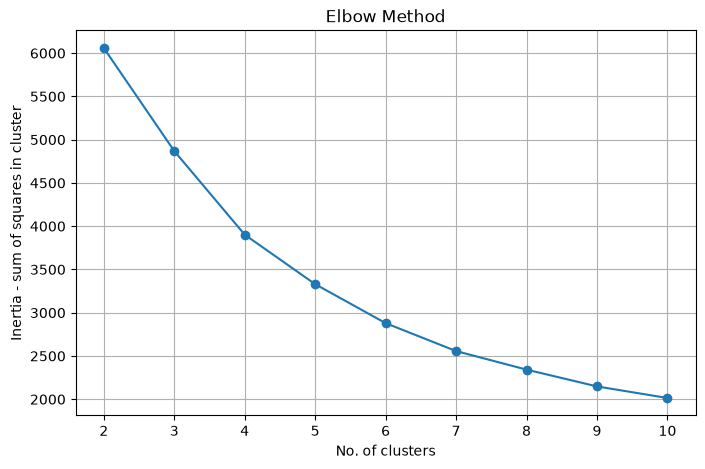

In [13]:
#Elbow method optimization using KMeans
inertia=[]
kval=range(2,11)
for k in kval:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(pca_cols)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(kval,inertia, marker='o')
plt.xlabel("No. of clusters")
plt.ylabel("Inertia - sum of squares in cluster")
plt.title("Elbow Method")
plt.xticks(kval)
plt.grid(True)
plt.show()


Silhouette Scores
k=2
Silhouette Score=0.291

k=3
Silhouette Score=0.265

k=4
Silhouette Score=0.279

k=5
Silhouette Score=0.279

k=6
Silhouette Score=0.279

k=7
Silhouette Score=0.281

k=8
Silhouette Score=0.274

k=9
Silhouette Score=0.267

k=10
Silhouette Score=0.256



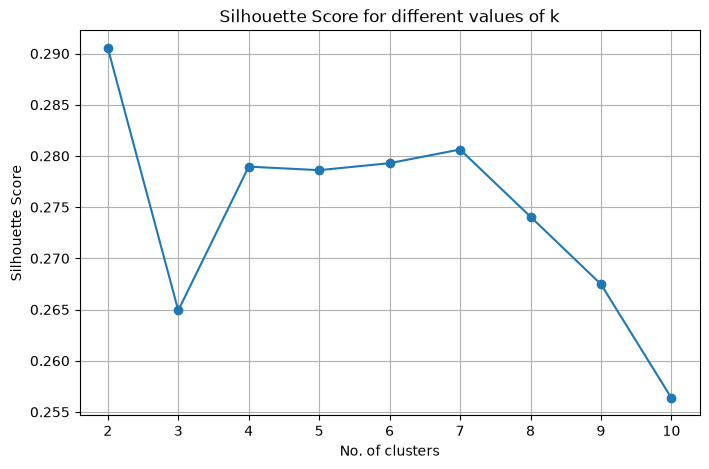


Best k according to silhouette score :  2


In [14]:
#Silhouette score evaluation
silhouette_scores=[]
for k in kval:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=kmeans.fit_predict(pca_cols)
    sil_score=silhouette_score(pca_cols,labels)
    silhouette_scores.append(sil_score)

print("\nSilhouette Scores")
for k,score in zip(kval,silhouette_scores):
    print(f"k={k}\nSilhouette Score={score:.3f}\n")

plt.figure(figsize=(8,5))
plt.plot(kval,silhouette_scores,marker='o')
plt.xlabel("No. of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for different values of k")
plt.xticks(kval)
plt.grid(True)
plt.show()

k_best=kval[np.argmax(silhouette_scores)]
print("\nBest k according to silhouette score : ",k_best)


Cluster distribution
 Cluster
0    626
1    566
Name: count, dtype: int64


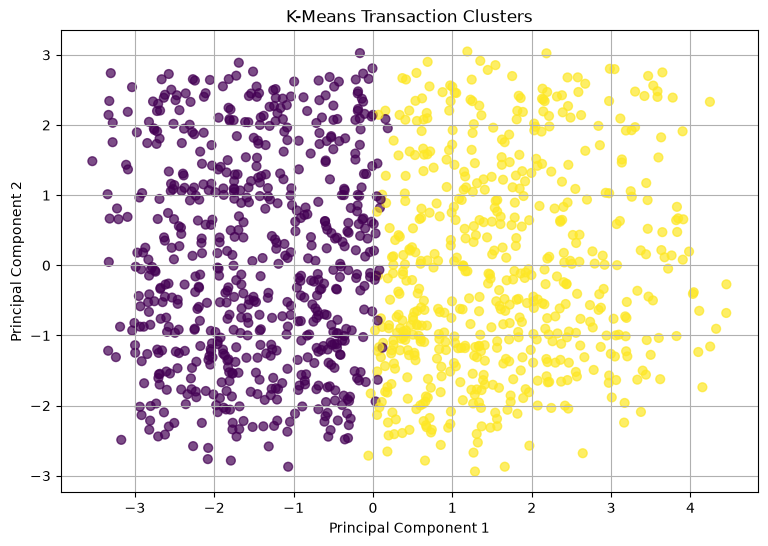

In [15]:
#Final clustering and visualization
kmeans_model=KMeans(n_clusters=k_best,random_state=42,n_init=10)
final_labels=kmeans_model.fit_predict(pca_cols)
df['Cluster']=final_labels

print("\nCluster distribution\n",df['Cluster'].value_counts().sort_index())
plt.figure(figsize=(9,6))
plt.scatter(pca_df['PCA1'],pca_df['PCA2'],c=final_labels,s=40,alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Transaction Clusters")
plt.grid(True)
plt.show()

In [16]:
#Cluster profiling
cluster_profile = df.groupby('Cluster').agg({'Quantity': 'mean','UnitPrice': 'mean','ItemsInCart': 'mean','TotalPrice': 'mean','PricePerItem': 'mean','CartValuePerItem': 'mean','HasCoupon': 'mean'}).round(2)
print(f"\nCluster profile\n{cluster_profile}")
cluster_profile['Customers/Orders']=df['Cluster'].value_counts().sort_index()
print(f"\nFinal cluster profile\n{cluster_profile}")

print("Most common product by cluster")
for cluster in sorted(df['Cluster'].unique()):
    print(f"Cluster {cluster}")
    print(f"Most common product :",df[df['Cluster']==cluster]['Product'].value_counts().idxmax())

print("Most common payment method by cluster")
for cluster in sorted(df['Cluster'].unique()):
    print(f"Cluster {cluster}")
    print(f"Most common payment method :",df[df['Cluster']==cluster]['PaymentMethod'].value_counts().idxmax())

print("Most common order status by cluster")
for cluster in sorted(df['Cluster'].unique()):
    print(f"Cluster {cluster}")
    print(f"Most common order status :",df[df['Cluster']==cluster]['OrderStatus'].value_counts().idxmax())


Cluster profile
         Quantity  UnitPrice  ItemsInCart  TotalPrice  PricePerItem  \
Cluster                                                               
0            2.67     201.79         5.34      491.86        201.79   
1            3.22     522.91         5.63     1642.80        522.91   

         CartValuePerItem  HasCoupon  
Cluster                               
0                  101.78       0.74  
1                  320.80       0.74  

Final cluster profile
         Quantity  UnitPrice  ItemsInCart  TotalPrice  PricePerItem  \
Cluster                                                               
0            2.67     201.79         5.34      491.86        201.79   
1            3.22     522.91         5.63     1642.80        522.91   

         CartValuePerItem  HasCoupon  Customers/Orders  
Cluster                                                 
0                  101.78       0.74               626  
1                  320.80       0.74               566  
Most c

In [17]:
#Business persona translation
print("\nBusiness Persona Analysis")
overall_spending = df['TotalPrice'].mean()
overall_quantity = df['Quantity'].mean()
overall_cart = df['ItemsInCart'].mean()

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]

    avg_spending = cluster_data['TotalPrice'].mean()
    avg_quantity = cluster_data['Quantity'].mean()
    avg_cart = cluster_data['ItemsInCart'].mean()
    coupon_rate = cluster_data['HasCoupon'].mean()
    if (avg_spending > overall_spending and avg_quantity > overall_quantity):
        persona = "High value buyers"
    elif (avg_quantity > overall_quantity and avg_spending <= overall_spending):
        persona = "Frequent buyers"
    elif (avg_spending > overall_spending and avg_quantity <= overall_quantity):
        persona = "Premium buyers"
    else:
        persona = "Low value buyers"
    print("\nCluster :", cluster)
    print("Persona :", persona)
    print("Average Total Price :", round(avg_spending, 2))
    print("Average Quantity :",round(avg_quantity, 2))
    print("Average Items in Cart :",round(avg_cart, 2))
    print("Coupon Usage Rate :",round(coupon_rate * 100, 2),"%")


Business Persona Analysis

Cluster : 0
Persona : Low value buyers
Average Total Price : 491.86
Average Quantity : 2.67
Average Items in Cart : 5.34
Coupon Usage Rate : 74.28 %

Cluster : 1
Persona : High value buyers
Average Total Price : 1642.8
Average Quantity : 3.22
Average Items in Cart : 5.63
Coupon Usage Rate : 74.2 %


In [18]:
#Saving final dataset
df.to_csv("clustered_dataset.csv",index=False)
print("\nFinal dataset saved as clustered_dataset.csv")


Final dataset saved as clustered_dataset.csv
